## In this notebook we will learn about Assumptions of Linear Regression

# 1) Assumption of Linearity 
- There should be linear relationship between independent variables and dependent variable

## To check this Assumption

### I - Scatter plot of  Independent variables with Dependent vairable
- This will give us an idea about relationship of independent and dependent variable

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100,1)

df = pd.DataFrame()

df["x1"] = x.reshape(100)
df["x2"] = y.reshape(100)
df["y"] = z.reshape(100)
df.head()

,x1,x2,y
0,3.871763,1.521827,20.740300
1,-1.035783,1.313304,5.112468
2,-2.287878,-0.306970,5.481949
3,1.184578,0.561817,3.388749
4,3.181051,-2.316455,16.829346


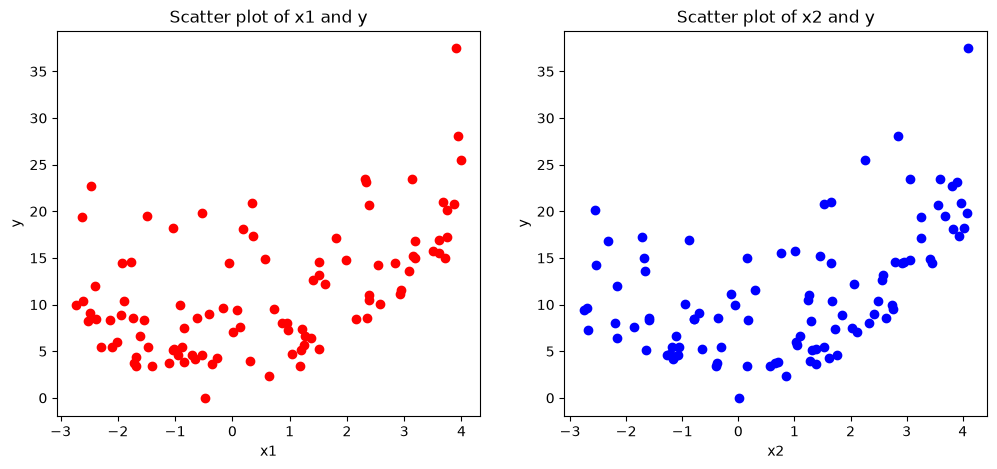

In [2]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))

# Plot x1 and y
ax1.scatter(df["x1"], df["y"], color="red")
ax1.set_title("Scatter plot of x1 and y")
ax1.set_xlabel("x1")
ax1.set_ylabel("y")

# plot x2 and y
ax2.scatter(df["x2"], df["y"], color="blue")
ax2.set_title("Scatter plot of x2 and y")
ax2.set_xlabel("x2")
ax2.set_ylabel("y")

plt.show()

## II - Residual Plot 
- If our Residual plot is scattered Randomly then Assumption of Linearity is not violated means our data is Linear and if our Residual plot follows a pattern it means our data is not linear

Text(0, 0.5, 'Residuals')

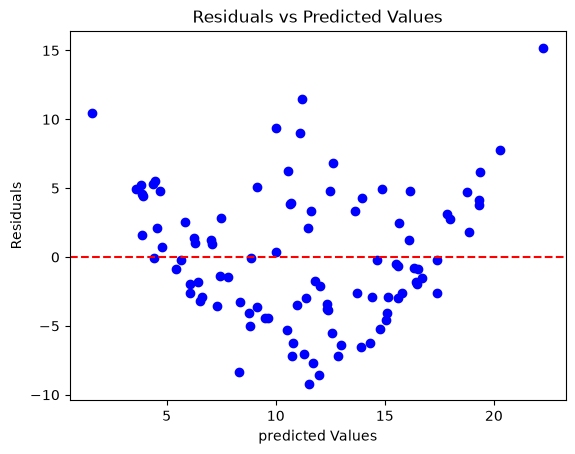

In [5]:
from sklearn.linear_model import LinearRegression

X = df[["x1", "x2"]]
y = df["y"]

model = LinearRegression()
model.fit(X,y)

y_pred = model.predict(X)
residuals = y - y_pred

plt.scatter(y_pred, residuals, color="blue")
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("predicted Values")
plt.ylabel("Residuals")

### III - Adding polynomial Term to my model and compare the model fit with the original model 
- if performance increase after adding Polynomial terms it means Assumption is violated

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Fit Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, linear_pred)

# Fit a Polynomial model
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_pred = poly_model.predict(X_test_poly)

poly_r2 = r2_score(y_test, poly_pred)

# Compare model performance
print("Linear Model")
print(f"R-Squared: {linear_r2:.4f}")

print("\nPolynomial model")
print(f"R-Squared: {poly_r2:.4f}")

Linear Model
R-Squared: 0.5600

Polynomial model
R-Squared: 0.9775


## Steps Taken when Assumption fails

### Step - I Applying Transformation
- In this example we use Sqaure root transformation but instead of Square root we can also use Box-Cox and Yeo-johnson
- We can also just use Polynomial Regression and can use non-parameteric methods

In [21]:
np.random.seed(42)
x = 10* np.random.rand(100,1)
y = x**2 + 5 + np.random.normal(0,5,(100,1))
y = np.abs(y) # Ensure y is positive 

# Applying Square-root transformation to y
y_sqrt = np.sqrt(y)

# Fit the linear regression models for the original and transformed data 
linear_org = LinearRegression()
linear_org.fit(x,y)

linear_trans = LinearRegression()
linear_trans.fit(x,y_sqrt)

# Prediction
y_pred_org = linear_org.predict(x)
y_pred_trans = linear_trans.predict(x)

# r2 Score
r2_original = r2_score(y,y_pred_org)
r2_transformed = r2_score(y_sqrt,y_pred_trans)

# Compare before and after transformation 
print("Original Linear model")
print(f"R-Squared: {r2_original:.4f}")

print("\nTransformed Linear model")
print(f"R-Squared: {r2_transformed:.4f}")

Original Linear model
R-Squared: 0.9008

Transformed Linear model
R-Squared: 0.9291


# 2) Normality of Residuals
- The error terms(Residuals) are assumed to follow a normal distribution 

## To check this Assumption

## Step - I ) Histogram and QQ Plot of Residuals

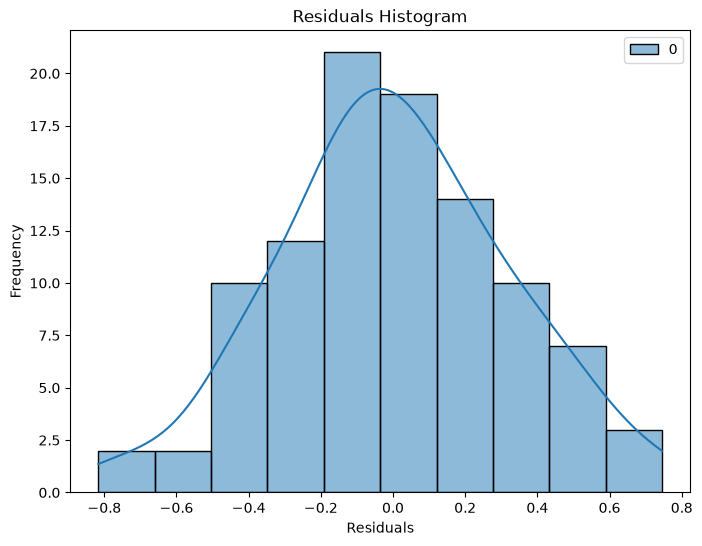

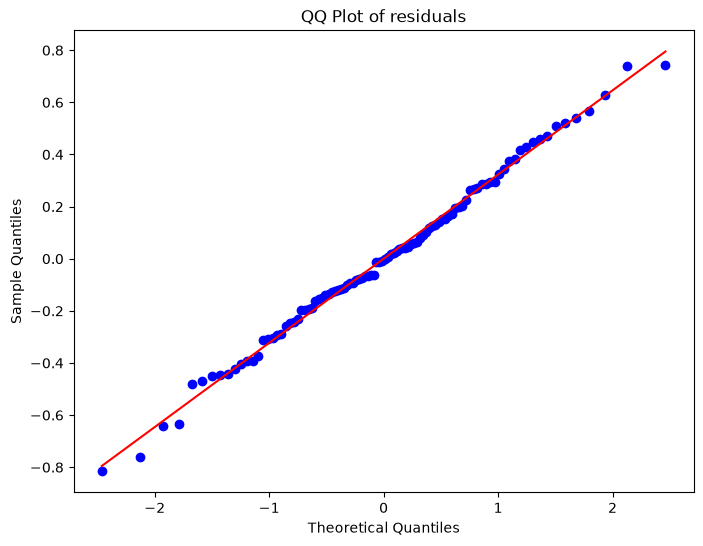

In [28]:
import seaborn as sns
from scipy import stats

x = np.random.rand(100,1)
y = 3*x + np.random.normal(0,0.3,(100,1))

model = LinearRegression()
model.fit(x,y)
y_pred = model.predict(x)

# Calculate the residuals 
residuals = y - y_pred

# Histogram
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residuals Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


# QQ Plot
plt.figure(figsize=(8,6))
stats.probplot(residuals.flatten(), plot=plt)
plt.title("QQ Plot of residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

## Step-II) Omnibus-Test
- Its null hypothesis states that residuals are normally distributed and the Alternate hypothesis says that the residuals are not normally distributed

In [32]:
x = np.random.rand(100,1)
y = 3*x + np.random.normal(0,0.3,(100,1))

model = LinearRegression()
model.fit(x,y)
y_pred = model.predict(x)

# Calculate the residuals 
residuals = y - y_pred

# Calculate skewness, kurtosis, Omnibus test statistic and p-value
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)
omnibus_stat, omnibus_p_value = stats.normaltest(residuals)


print(f"Skewness: {skewness[0]:.4f}")
print(f"Kurtosis: {kurtosis[0]:.4f}")
print(f"Omnibus Test Statistic: {omnibus_stat[0]:.4f}")
print(f"Omnibus Test P-value: {omnibus_p_value[0]:.4f}")

Skewness: -0.2543
Kurtosis: -0.1401
Omnibus Test Statistic: 1.1908
Omnibus Test P-value: 0.5513


# 3) Homoscedasticity
- Variance of Residuals should be constant across all predicted values

Text(0, 0.5, 'y2')

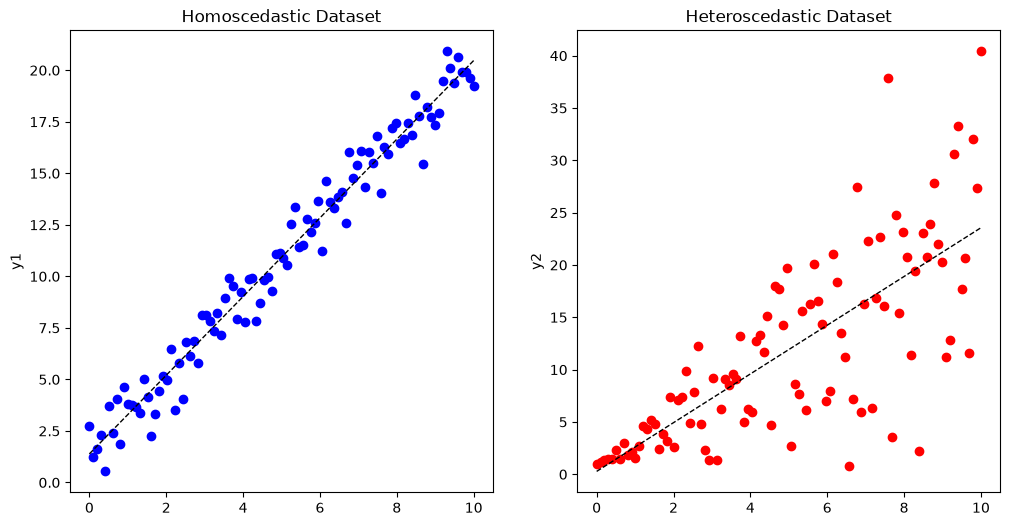

In [45]:
x = np.linspace(0,10,100)

# homoscedastic Dataset
y1 = 2 * x + 1 + np.random.normal(0,1,len(x))

# Heteroscedastic dataset
y2 = 2 * x + 1 + np.random.normal(0,x,len(x))

# fit the linear models
coeffs1 = np.polyfit(x,y1,1)
y1_pred = np.polyval(coeffs1,x)
residuals1 = y1 - y1_pred

coeffs2 = np.polyfit(x,y2,1)
y2_pred = np.polyval(coeffs2,x)
residuals2 = y2 - y2_pred

# Plot the residuals and dataset
fig, axes = plt.subplots(1,2, figsize=(12,6), sharex=True)

axes[0].scatter(x,y1,color="blue")
axes[0].plot(x,y1_pred, color="black",linestyle="--", lw=1)
axes[0].set_title("Homoscedastic Dataset")
axes[0].set_ylabel("y1")

axes[1].scatter(x,y2,color="red")
axes[1].plot(x,y2_pred, color="black",linestyle="--", lw=1)
axes[1].set_title("Heteroscedastic Dataset")
axes[1].set_ylabel("y2")